# 01. Exploratory Data Analysis (EDA)

En este cuaderno de trabajo se desarrolla un Análisis Exploratorio de Datos (EDA) exhaustivo para evaluar la estructura, calidad, integridad y balance del dataset de imágenes satelitales diseñado para la detección de minería ilegal (garimpo) en la selva amazónica. Este análisis sirve como base diagnóstica para verificar la idoneidad del conjunto de datos antes de entrenar redes neuronales convolucionales (CNN).

## 1. Introduction

La minería ilegal en la cuenca del Amazonas genera una degradación forestal severa que puede ser monitoreada mediante sensores satelitales. En esta introducción se plantea la importancia de procesar metadatos e imágenes para construir modelos supervisados de clasificación binaria. A lo largo del análisis exploratorio, buscaremos inconsistencias en la base de datos, evaluaremos la distribución de clases y caracterizaremos visual y estadísticamente las propiedades espectrales y geométricas de los parches de imagen.

## 2. Dataset Loading

Esta sección comprende la carga de la librería fundamental de manipulación de datos (Pandas), cálculo numérico (NumPy), visualización (Matplotlib, Seaborn) y procesamiento de imágenes (OpenCV). Posteriormente, se carga el archivo de metadatos manifesto_chips.csv que contiene los registros de cada parche de imagen satelital para realizar el diagnóstico y la exploración inicial.

### 2.1 Load Metadata

In [127]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

DATA_PATH = Path("../data/01_raw")
CSV_PATH = DATA_PATH / "manifesto_chips.csv"
df = pd.read_csv(CSV_PATH)

### 2.2 Initial Data Inspection

In [128]:
df.head()

,png_path,tif_source,label_str,label_int,tile_row,tile_col,tile_size_px,utm_epsg,overlap_area_m2,overlap_ratio,...,ymax,centroid_lon,centroid_lat,crs_raster,transform,width_px,height_px,bands_used,dtype_src,nodata
0,sem_garimpo/v3_new_ret_s2_median_2024_dry-0000...,v3_new_ret_s2_median_2024_dry-0000000000-00000...,sem_garimpo,0,0,0,128,32721,0.0,0.0,...,-4.495799,-58.332911,-4.501548,EPSG:4326,"(8.983152841195215e-05, 0.0, -58.3386606758752...",13568,13568,"['B4', 'B3', 'B2']",float32,NaN
1,sem_garimpo/v3_new_ret_s2_median_2024_dry-0000...,v3_new_ret_s2_median_2024_dry-0000000000-00000...,sem_garimpo,0,0,1,128,32721,0.0,0.0,...,-4.495799,-58.321413,-4.501548,EPSG:4326,"(8.983152841195215e-05, 0.0, -58.3386606758752...",13568,13568,"['B4', 'B3', 'B2']",float32,NaN
2,sem_garimpo/v3_new_ret_s2_median_2024_dry-0000...,v3_new_ret_s2_median_2024_dry-0000000000-00000...,sem_garimpo,0,0,2,128,32721,0.0,0.0,...,-4.495799,-58.309915,-4.501548,EPSG:4326,"(8.983152841195215e-05, 0.0, -58.3386606758752...",13568,13568,"['B4', 'B3', 'B2']",float32,NaN
3,sem_garimpo/v3_new_ret_s2_median_2024_dry-0000...,v3_new_ret_s2_median_2024_dry-0000000000-00000...,sem_garimpo,0,0,3,128,32721,0.0,0.0,...,-4.495799,-58.298416,-4.501548,EPSG:4326,"(8.983152841195215e-05, 0.0, -58.3386606758752...",13568,13568,"['B4', 'B3', 'B2']",float32,NaN
4,sem_garimpo/v3_new_ret_s2_median_2024_dry-0000...,v3_new_ret_s2_median_2024_dry-0000000000-00000...,sem_garimpo,0,0,4,128,32721,0.0,0.0,...,-4.495799,-58.286918,-4.501548,EPSG:4326,"(8.983152841195215e-05, 0.0, -58.3386606758752...",13568,13568,"['B4', 'B3', 'B2']",float32,NaN


## 3. General Information

En esta sección se analiza la estructura general de la tabla de metadatos cargada. Se revisa el volumen de datos (filas y columnas), los tipos de variables registradas (numéricas, cadenas o booleanas) y se cuantifica la presencia de valores nulos o ausentes en cada columna, lo que nos permite determinar si el dataset requiere de algún tratamiento de imputación o limpieza antes del modelado.

### 3.1 Dataset Dimensions

In [129]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas: 111,584
Columnas: 27


### 3.2 Data Types

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111584 entries, 0 to 111583
Data columns (total 27 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   png_path         111584 non-null  object 
 1   tif_source       111584 non-null  object 
 2   label_str        111584 non-null  object 
 3   label_int        111584 non-null  int64  
 4   tile_row         111584 non-null  int64  
 5   tile_col         111584 non-null  int64  
 6   tile_size_px     111584 non-null  int64  
 7   utm_epsg         111584 non-null  int64  
 8   overlap_area_m2  111584 non-null  float64
 9   overlap_ratio    111584 non-null  float64
 10  xmin_m           111584 non-null  float64
 11  ymin_m           111584 non-null  float64
 12  xmax_m           111584 non-null  float64
 13  ymax_m           111584 non-null  float64
 14  xmin             111584 non-null  float64
 15  ymin             111584 non-null  float64
 16  xmax             111584 non-null  floa

### 3.3 Missing Values

In [131]:
df.isna().sum().sort_values(ascending=False)

nodata             111584
tif_source              0
png_path                0
label_int               0
tile_row                0
tile_col                0
tile_size_px            0
utm_epsg                0
overlap_area_m2         0
overlap_ratio           0
label_str               0
xmin_m                  0
ymin_m                  0
ymax_m                  0
xmax_m                  0
ymin                    0
xmax                    0
ymax                    0
xmin                    0
centroid_lon            0
centroid_lat            0
transform               0
crs_raster              0
width_px                0
height_px               0
bands_used              0
dtype_src               0
dtype: int64

## 4. Class Distribution

El análisis del balance de clases evalúa la proporción de imágenes con presencia de minería ilegal (com_garimpo) frente a las áreas sin alteración o de bosque (sem_garimpo). Conocer si el dataset está balanceado o desbalanceado es crítico para seleccionar adecuadamente la función de pérdida del modelo y las métricas de evaluación durante la fase de entrenamiento.

### 4.1 Number of Images per Class

In [132]:
df["label_str"].value_counts()

label_str
sem_garimpo    56043
com_garimpo    55541
Name: count, dtype: int64

### 4.2 Class Balance

label_str
sem_garimpo    50.22
com_garimpo    49.78
Name: proportion, dtype: float64


C:\Users\36nue\AppData\Local\Temp\ipykernel_15124\3360245915.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label_str", palette="viridis")


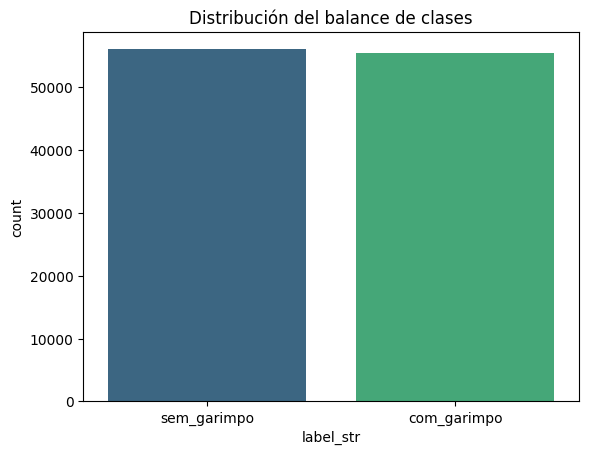

In [133]:
porcentajes = df["label_str"].value_counts(normalize=True).mul(100).round(2)
print(porcentajes)

sns.countplot(data=df, x="label_str", palette="viridis")
plt.title("Distribución del balance de clases")
plt.show()

## 5. Dataset Integrity

Aquí se verifica la concordancia entre los metadatos tabulares y los archivos físicos en disco. Se construyen las rutas de los parches de imagen y se analiza sistemáticamente si existen archivos faltantes o corruptos (que no puedan ser decodificados correctamente por OpenCV), garantizando que el canal de datos durante el entrenamiento no falle inesperadamente.

### 5.1 Image Path Validation

In [134]:
CHIPS_DIR = DATA_PATH / "dataset_amazonia_garimpo_binario"
df["full_path"] = df["png_path"].apply(lambda x: CHIPS_DIR / x)

### 5.2 Missing Images Detection

In [135]:
missing = df["full_path"].apply(lambda p: not p.exists()).sum()
print(f"Imágenes faltantes en el disco: {missing}")

Imágenes faltantes en el disco: 0


### 5.3 Corrupted Images Detection

In [136]:
sample_df = df.sample(n=min(5000, len(df)), random_state=42)
corrupted = 0
for path in sample_df["full_path"]:
    if path.exists():
        try:
            img = cv2.imread(str(path))
            if img is None:
                corrupted += 1
        except Exception:
            corrupted += 1
print(f"Imágenes corruptas encontradas en la muestra analizada: {corrupted}")

Imágenes corruptas encontradas en la muestra analizada: 0


## 6. Image Properties

En esta sección se analizan las propiedades básicas de las imágenes del dataset. Se estudia la dimensión de las imágenes satelitales raster originales en comparación con el tamaño físico de los parches individuales recortados (chips) de entrenamiento, permitiendo diferenciar entre el tamaño total de la captura y la resolución de las muestras ingresadas en el modelo.

### 6.1 Image Dimensions

#### 6.1.1 Source Raster Dimensions

In [137]:
print("Estadísticas de las dimensiones de los rasters originales:")
print(df[["width_px", "height_px"]].describe())

print(f"\nCantidad total de imágenes satelitales (rasters) originales únicas: {df['tif_source'].nunique()}")

Estadísticas de las dimensiones de los rasters originales:
            width_px      height_px
count  111584.000000  111584.000000
mean    13562.700315   12680.909091
std         7.530525    2712.964907
min     13552.000000    4384.000000
25%     13552.000000   13568.000000
50%     13568.000000   13568.000000
75%     13568.000000   13568.000000
max     13568.000000   13568.000000

Cantidad total de imágenes satelitales (rasters) originales únicas: 12


#### 6.1.2 Training Chip Dimensions

In [138]:
print("Estadísticas de tile_size_px en los metadatos:")
print(df["tile_size_px"].describe())

sample_sizes = [cv2.imread(str(p)).shape for p in sample_df["full_path"] if p.exists()]
unique_sizes = set(sample_sizes)
print(f"Dimensiones físicas únicas detectadas en los archivos de la muestra: {unique_sizes}")

Estadísticas de tile_size_px en los metadatos:
count    111584.0
mean        128.0
std           0.0
min         128.0
25%         128.0
50%         128.0
75%         128.0
max         128.0
Name: tile_size_px, dtype: float64
Dimensiones físicas únicas detectadas en los archivos de la muestra: {(128, 128, 3)}


### 6.2 Color Channels

In [139]:
df["bands_used"].value_counts()

bands_used
['B4', 'B3', 'B2']    111584
Name: count, dtype: int64

## 7. Image Visualization

La inspección visual cualitativa permite validar la categorización de los datos. En este apartado se cargan y grafican de manera aleatoria muestras visuales de parches de imágenes pertenecientes a ambas clases (con y sin presencia de minería ilegal), lo que nos da una intuición directa sobre los patrones espaciales y texturas característicos de la deforestación.

### 7.1 Illegal Mining Samples

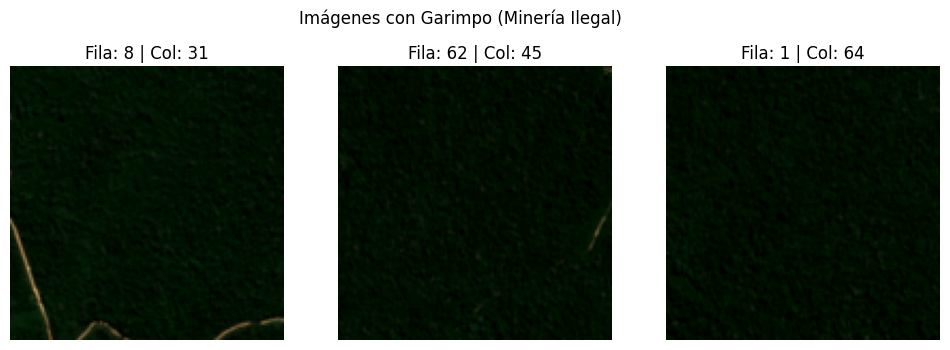

In [140]:
mining_samples = df[df["label_str"] == "com_garimpo"].sample(n=min(3, len(df)), random_state=42)
fig, axes = plt.subplots(1, min(3, len(mining_samples)), figsize=(12, 4))
for i, (_, row) in enumerate(mining_samples.iterrows()):
    path = row["full_path"]
    if path.exists():
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"Fila: {row['tile_row']} | Col: {row['tile_col']}")
plt.suptitle("Imágenes con Garimpo (Minería Ilegal)")
plt.show()

### 7.2 Non-Illegal Mining Samples

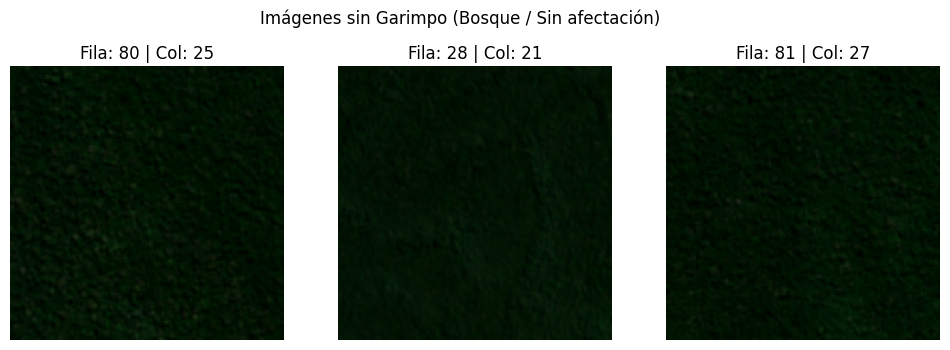

In [141]:
non_mining_samples = df[df["label_str"] == "sem_garimpo"].sample(n=min(3, len(df)), random_state=42)
fig, axes = plt.subplots(1, min(3, len(non_mining_samples)), figsize=(12, 4))
for i, (_, row) in enumerate(non_mining_samples.iterrows()):
    path = row["full_path"]
    if path.exists():
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"Fila: {row['tile_row']} | Col: {row['tile_col']}")
plt.suptitle("Imágenes sin Garimpo (Bosque / Sin afectación)")
plt.show()

## 8. Image Quality Analysis

Esta sección aborda un análisis numérico de la calidad visual de los parches de imagen. Para optimizar el tiempo de cómputo del notebook y mantener la fluidez del análisis, se evalúa una muestra aleatoria de $n = 5,000$ imágenes.

Desde una perspectiva estadística, un tamaño muestral de 5,000 unidades sobre un universo de $N = 111,584$ garantiza una alta robustez. El margen de error ($E$) para un nivel de confianza del 95% ($Z = 1.96$) y variabilidad máxima ($p = 0.5$) se calcula mediante la fórmula estándar para poblaciones finitas:

$$E = Z \cdot \sqrt{\frac{p \cdot (1-p)}{n} \cdot \left(\frac{N-n}{N-1}\right)}$$

Reemplazando los valores en la ecuación:

$$E = 1.96 \cdot \sqrt{\frac{0.5 \cdot 0.5}{5000} \cdot \left(\frac{111584-5000}{111584-1}\right)} \approx 1.35\%$$

Por tanto, analizar 5,000 imágenes aleatorias garantiza un margen de error de aproximadamente $\pm 1.35\%$ con un nivel de confianza del 95%, reflejando con gran precisión las propiedades de brillo, contraste e histogramas RGB de la totalidad del dataset.

### 8.1 Brightness Analysis

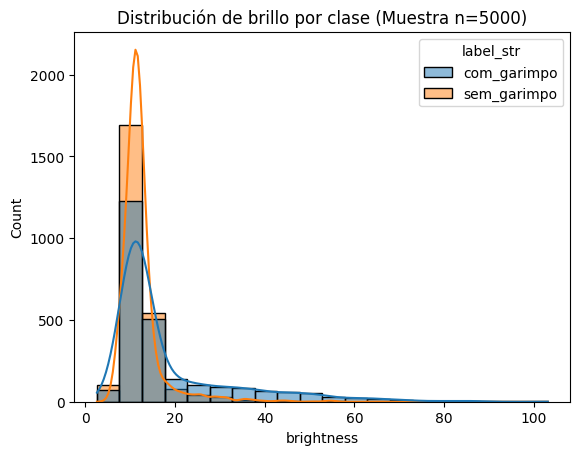

com_garimpo - Brillo: Media=18.36 | Mediana (Pico)=12.45 | Std=13.87 | Rango=[2.6, 103.1]
sem_garimpo - Brillo: Media=12.35 | Mediana (Pico)=11.47 | Std=4.78 | Rango=[5.1, 55.4]


In [142]:
def get_brightness(p):
    if not p.exists(): return np.nan
    img = cv2.imread(str(p))
    if img is None: return np.nan
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.mean()

sample_df = df.sample(n=min(5000, len(df)), random_state=42).copy()
sample_df["brightness"] = sample_df["full_path"].apply(get_brightness)

sns.histplot(data=sample_df, x="brightness", hue="label_str", kde=True, bins=20)
plt.title("Distribución de brillo por clase (Muestra n=5000)")
plt.show()

# Estadísticas numéricas clave representadas en el gráfico
for cls in sample_df["label_str"].dropna().unique():
    sub = sample_df[sample_df["label_str"] == cls]["brightness"].dropna()
    print(f"{cls} - Brillo: Media={sub.mean():.2f} | Mediana (Pico)={sub.median():.2f} | Std={sub.std():.2f} | Rango=[{sub.min():.1f}, {sub.max():.1f}]")

### 8.2 Contrast Analysis

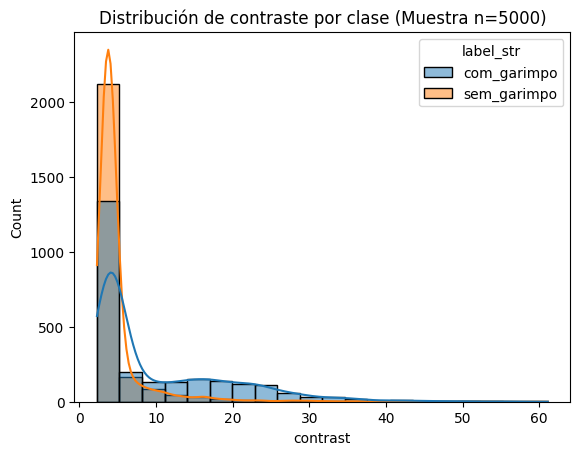

com_garimpo - Contraste: Media=10.21 | Mediana (Pico)=4.78 | Std=9.09 | Rango=[2.8, 61.1]
sem_garimpo - Contraste: Media=5.01 | Mediana (Pico)=3.85 | Std=4.47 | Rango=[2.3, 59.4]


In [143]:
def get_contrast(p):
    if not p.exists(): return np.nan
    img = cv2.imread(str(p))
    if img is None: return np.nan
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.std()

sample_df["contrast"] = sample_df["full_path"].apply(get_contrast)

sns.histplot(data=sample_df, x="contrast", hue="label_str", kde=True, bins=20)
plt.title("Distribución de contraste por clase (Muestra n=5000)")
plt.show()

# Estadísticas numéricas clave representadas en el gráfico
for cls in sample_df["label_str"].dropna().unique():
    sub = sample_df[sample_df["label_str"] == cls]["contrast"].dropna()
    print(f"{cls} - Contraste: Media={sub.mean():.2f} | Mediana (Pico)={sub.median():.2f} | Std={sub.std():.2f} | Rango=[{sub.min():.1f}, {sub.max():.1f}]")

### 8.3 RGB Histogram Analysis

Canal B - Intensidad máxima en: 0 (pico de frecuencia)
Canal G - Intensidad máxima en: 18 (pico de frecuencia)
Canal R - Intensidad máxima en: 0 (pico de frecuencia)


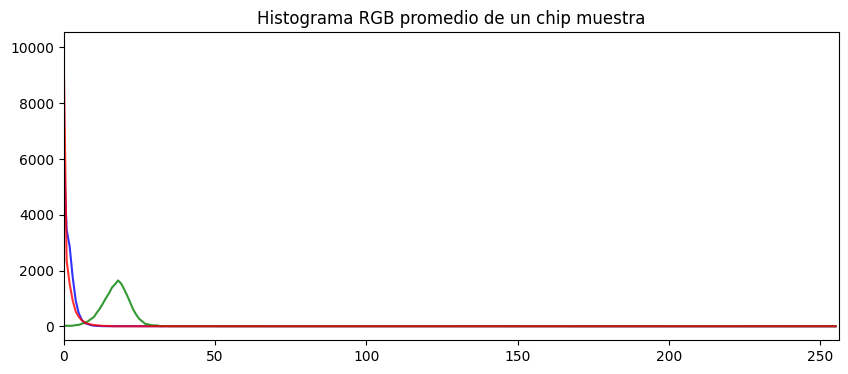

In [144]:
plt.figure(figsize=(10, 4))
valid_paths = [p for p in sample_df["full_path"] if p.exists()]
if valid_paths:
    img = cv2.imread(str(valid_paths[0]))
    colors = ("b", "g", "r")
    for i, col in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color=col, alpha=0.8)
        print(f"Canal {col.upper()} - Intensidad máxima en: {np.argmax(hist)} (pico de frecuencia)")
    plt.title("Histograma RGB promedio de un chip muestra")
    plt.xlim([0, 256])
plt.show()

## 9. Duplicate Image Detection

La presencia de imágenes duplicadas o registros redundantes puede causar un sobreajuste artificial y sesgar la evaluación del modelo si la misma imagen aparece en las divisiones de entrenamiento y validación. En esta sección se analiza y cuantifica la existencia de registros duplicados en función del nombre y la ruta relativa de las imágenes de satélite.

In [145]:
duplicados = df["png_path"].duplicated().sum()
print(f"Rutas de imágenes duplicadas: {duplicados}")

Rutas de imágenes duplicadas: 0


## 10. Metadata Analysis

En esta sección se exploran las variables espaciales de los parches satelitales. Específicamente, se analiza la tasa de solapamiento (overlap ratio) y la superficie física del solapamiento en metros cuadrados (overlap area) entre los chips vecinos extraídos. Esta información ayuda a cuantificar la correlación espacial que existe entre parches contiguos y a evitar la fuga de datos.

### 10.1 Overlap Ratio

In [146]:
df["overlap_ratio"].describe()

count    111584.000000
mean          0.499847
std           0.537887
min           0.000000
25%           0.000000
50%           0.023418
75%           1.000000
max           3.310692
Name: overlap_ratio, dtype: float64

### 10.2 Overlap Area

In [147]:
df["overlap_area_m2"].describe()

count    1.115840e+05
mean     8.079945e+05
std      8.694514e+05
min      0.000000e+00
25%      0.000000e+00
50%      3.793281e+04
75%      1.615848e+06
max      5.352476e+06
Name: overlap_area_m2, dtype: float64

## 11. Raster-Level Analysis

En esta sección se examina el dataset desde la perspectiva de los rasters originales (archivos `.tif`) a partir de los cuales se generaron los chips de entrenamiento. El objetivo es comprender cuántos chips provienen de cada raster, cómo se distribuyen las clases a nivel de imagen satelital y si la distribución espacial permite realizar una partición (train/val/test) por raster sin introducir sesgo o fuga de datos.

### 11.1 Number of Chips per Raster

Estadísticas descriptivas — chips por raster:
count       12.00
mean      9298.67
std       3441.15
min       3570.00
25%       9248.50
50%      11183.00
75%      11236.00
max      11236.00
Name: n_chips, dtype: float64


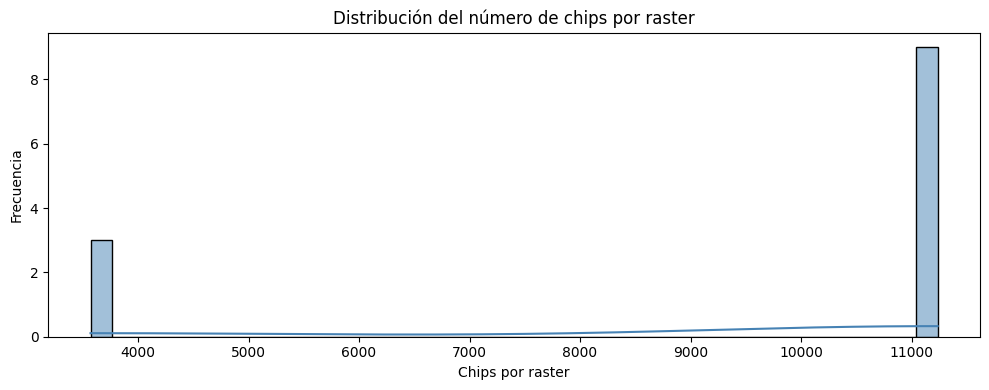

In [148]:
chips_per_raster = df.groupby('tif_source').size().rename('n_chips')

print('Estadísticas descriptivas — chips por raster:')
print(chips_per_raster.describe().round(2))

plt.figure(figsize=(10, 4))
sns.histplot(chips_per_raster, bins=40, kde=True, color='steelblue')
plt.title('Distribución del número de chips por raster')
plt.xlabel('Chips por raster')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### 11.2 Class Distribution per Raster

In [ ]:
class_per_raster = (
    df.groupby(['tif_source', 'label_str'])
      .size()
      .unstack(fill_value=0)
      .rename_axis(None, axis=1)
)

# Ensure both columns exist
for col in ['com_garimpo', 'sem_garimpo']:
    if col not in class_per_raster.columns:
        class_per_raster[col] = 0

class_per_raster['total'] = class_per_raster['com_garimpo'] + class_per_raster['sem_garimpo']

print(f'Rasters únicos: {len(class_per_raster)}')
print('\nPrimeras 10 filas de la tabla resumen:')
print(class_per_raster.sort_values('total', ascending=False).head(10))

Rasters únicos: 12

Primeras 10 filas de la tabla resumen:
                                                    com_garimpo  sem_garimpo  \
tif_source                                                                     
v3_new_ret_s2_median_2024_dry-0000000000-000000...         5229         6007   
v3_new_ret_s2_median_2024_dry-0000000000-000001...         6705         4531   
v3_new_ret_s2_median_2024_dry-0000013568-000000...         6493         4743   
v3_new_ret_s2_median_2024_dry-0000013568-000001...        10025         1211   
v3_new_ret_s2_median_2024_dry-0000027136-000001...         6371         4865   
v3_new_ret_s2_median_2024_dry-0000027136-000000...          673        10563   
v3_new_ret_s2_median_2024_dry-0000000000-000002...         2618         8512   
v3_new_ret_s2_median_2024_dry-0000013568-000002...         6117         5013   
v3_new_ret_s2_median_2024_dry-0000027136-000002...         9132         1998   
v3_new_ret_s2_median_2024_dry-0000040704-000000...           

### 11.3 Illegal Mining Ratio per Raster

Estadísticas del porcentaje de minería ilegal por raster:
count    12.00
mean     44.79
std      30.41
min       0.00
25%      19.14
50%      55.83
75%      59.88
max      89.22
Name: mining_ratio, dtype: float64


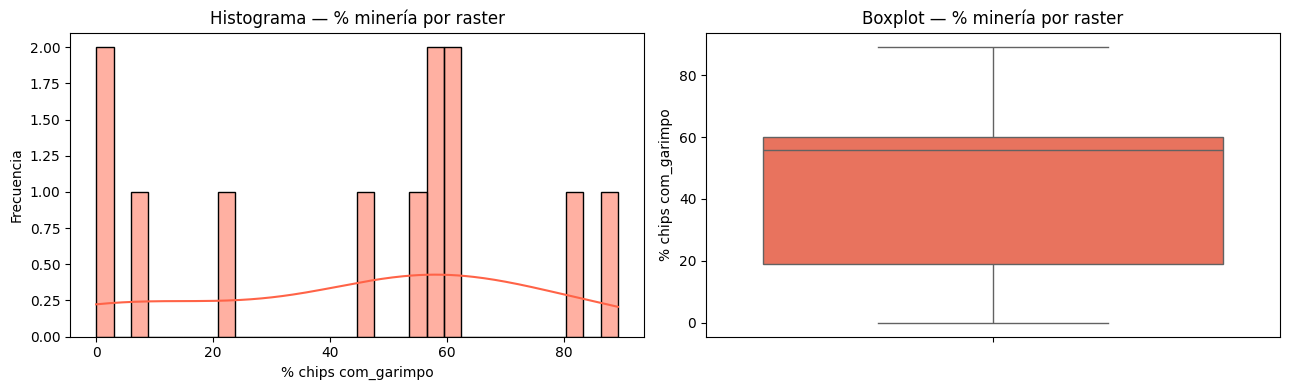

In [150]:
class_per_raster['mining_ratio'] = (
    class_per_raster['com_garimpo'] / class_per_raster['total'] * 100
).round(2)

print('Estadísticas del porcentaje de minería ilegal por raster:')
print(class_per_raster['mining_ratio'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(class_per_raster['mining_ratio'], bins=30, kde=True,
             color='tomato', ax=axes[0])
axes[0].set_title('Histograma — % minería por raster')
axes[0].set_xlabel('% chips com_garimpo')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(y=class_per_raster['mining_ratio'], color='tomato', ax=axes[1])
axes[1].set_title('Boxplot — % minería por raster')
axes[1].set_ylabel('% chips com_garimpo')

plt.tight_layout()
plt.show()

### 11.4 Raster Balance Assessment

Distribución de rasters por banda de minería:

        0% minería:    2 rasters (16.7%)
     1-25% minería:    2 rasters (16.7%)
    25-50% minería:    1 rasters (8.3%)
    50-75% minería:    5 rasters (41.7%)
   75-100% minería:    2 rasters (16.7%)

Rasters dominados por bosque (0% minería):    2
Rasters dominados por minería (100%):         0
Rasters relativamente balanceados (25-75%):   6


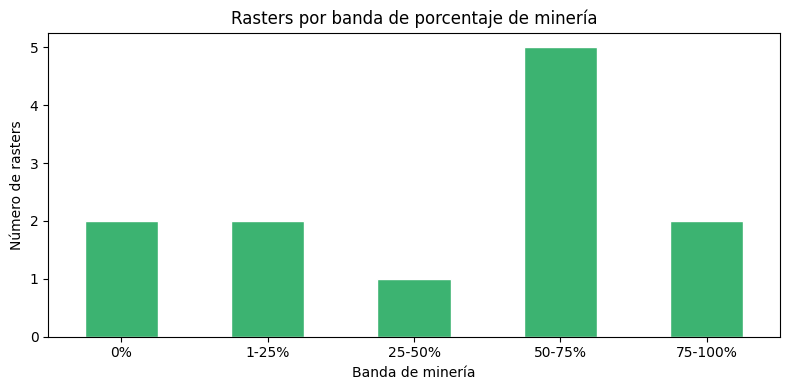

In [151]:
bins   = [0, 1, 25, 50, 75, 100]
labels = ['0%', '1-25%', '25-50%', '50-75%', '75-100%']

class_per_raster['mining_band'] = pd.cut(
    class_per_raster['mining_ratio'],
    bins=bins, labels=labels,
    include_lowest=True, right=True
)

band_counts = class_per_raster['mining_band'].value_counts().sort_index()
total_rasters = len(class_per_raster)

print('Distribución de rasters por banda de minería:\n')
for band, cnt in band_counts.items():
    pct = cnt / total_rasters * 100
    print(f'  {band:>8} minería: {cnt:>4} rasters ({pct:.1f}%)')

n_pure_forest  = band_counts.get('0%', 0)
n_pure_mining  = class_per_raster[class_per_raster['mining_ratio'] == 100].shape[0]
n_balanced     = class_per_raster[
    class_per_raster['mining_ratio'].between(25, 75)
].shape[0]

print(f'\nRasters dominados por bosque (0% minería):    {n_pure_forest}')
print(f'Rasters dominados por minería (100%):         {n_pure_mining}')
print(f'Rasters relativamente balanceados (25-75%):   {n_balanced}')

plt.figure(figsize=(8, 4))
band_counts.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Rasters por banda de porcentaje de minería')
plt.xlabel('Banda de minería')
plt.ylabel('Número de rasters')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 11.5 Spatial Split Feasibility Analysis

In [152]:
total_rasters = len(class_per_raster)
total_chips   = len(df)

# Simulated raster-level split (70/15/15)
raster_list = class_per_raster.sample(frac=1, random_state=42)
n_train = int(total_rasters * 0.70)
n_val   = int(total_rasters * 0.15)

train_rasters = set(raster_list.index[:n_train])
val_rasters   = set(raster_list.index[n_train:n_train + n_val])
test_rasters  = set(raster_list.index[n_train + n_val:])

df['split_raster'] = df['tif_source'].apply(
    lambda r: 'train' if r in train_rasters
              else ('val' if r in val_rasters else 'test')
)

print('─── Split por RASTER (70/15/15) ───')
for split in ['train', 'val', 'test']:
    sub = df[df['split_raster'] == split]
    n   = len(sub)
    ratio = sub['label_str'].value_counts(normalize=True).mul(100).round(1)
    com = ratio.get('com_garimpo', 0)
    sem = ratio.get('sem_garimpo', 0)
    print(f'  {split:5}: {n:>6} chips | com_garimpo {com}% | sem_garimpo {sem}%')

print('\n─── Split por CHIP (70/15/15) ───')
chip_split = df.sample(frac=1, random_state=42).copy()
n_tr = int(total_chips * 0.70)
n_vl = int(total_chips * 0.15)
chip_split['split_chip'] = (
    ['train'] * n_tr + ['val'] * n_vl + ['test'] * (total_chips - n_tr - n_vl)
)
for split in ['train', 'val', 'test']:
    sub = chip_split[chip_split['split_chip'] == split]
    n   = len(sub)
    ratio = sub['label_str'].value_counts(normalize=True).mul(100).round(1)
    com = ratio.get('com_garimpo', 0)
    sem = ratio.get('sem_garimpo', 0)
    print(f'  {split:5}: {n:>6} chips | com_garimpo {com}% | sem_garimpo {sem}%')

print("""
Conclusión:
  - Split por chip:   maximiza datos de entrenamiento y balance de clases,
    pero chips del mismo raster pueden estar en train y test simultáneamente
    (fuga de datos espacial).
  - Split por raster: garantiza independencia espacial entre particiones
    (ningún raster aparece en más de un split), a costa de una ligera
    variación en el balance de clases entre particiones.
  → Se recomienda el split por raster para evitar data leakage espacial.
""")

─── Split por RASTER (70/15/15) ───
  train:  66640 chips | com_garimpo 48.0% | sem_garimpo 52.0%
  val  :  11236 chips | com_garimpo 89.2% | sem_garimpo 10.8%
  test :  33708 chips | com_garimpo 40.2% | sem_garimpo 59.8%

─── Split por CHIP (70/15/15) ───
  train:  78108 chips | com_garimpo 49.7% | sem_garimpo 50.3%
  val  :  16737 chips | com_garimpo 49.6% | sem_garimpo 50.4%
  test :  16739 chips | com_garimpo 50.2% | sem_garimpo 49.8%

Conclusión:
  - Split por chip:   maximiza datos de entrenamiento y balance de clases,
    pero chips del mismo raster pueden estar en train y test simultáneamente
    (fuga de datos espacial).
  - Split por raster: garantiza independencia espacial entre particiones
    (ningún raster aparece en más de un split), a costa de una ligera
    variación en el balance de clases entre particiones.
  → Se recomienda el split por raster para evitar data leakage espacial.



## 12. Conclusions

Las conclusiones del análisis exploratorio resumen los hallazgos principales en torno a la integridad de los datos, el equilibrio de clases, las características cromáticas y métricas espaciales de las imágenes, así como la distribución espacial a nivel de raster. Estas observaciones permiten establecer las pautas para definir el preprocesamiento final (redimensionamiento, normalización de canales, técnicas de data augmentation) e instrumentar la división del dataset de forma estratificada y robusta, preferentemente por raster para evitar fugas de datos espaciales.